# 🎬 TUGAS BESAR (NLP) - Movie Review Sentiment Analysis Model

Tugas ini bertujuan untuk membangun model **Analisis Sentimen (Positif/Negatif)** menggunakan dataset IMDB Movie Reviews. Model ini nantinya akan diimplementasikan pada sebuah website review film.

Anggota Kelompok :
1. Anjeli Ritonga - 3222003
2. Cakra Arganata - 1223903
3. Meriyati - 3222004
4. Nurfazlyana - 3222302

## 📌 Spesifikasi:
1. **Dataset**: IMDB Movie Reviews via library `nltk`.
2. **Preprocessing**: Pembersihan teks (HTML, angka, spesial karakter), Case folding, Stopwords removal, dan Lemmatization.
3. **Feature Extraction**: `TfidfVectorizer` (Mengubah teks jadi angka).
4. **Modeling**: `Multinomial Naive Bayes` (Ringan dan efektif untuk klasifikasi teks, cocok untuk website).
5. **Evaluasi**: Accuracy Score dan Confusion Matrix.
6. **Export Model**: Mengekspor model sentimen dan TF-IDF Vectorizer ke file `.pkl` dengan `pickle`.

In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import re
import pickle

# NLTK untuk NLP tasks
import nltk
from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn untuk modeling dan evaluasi
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualisasi Evaluasi
import seaborn as sns
import matplotlib.pyplot as plt

# Download modul NLTK yang diperlukan (Bisa di-uncomment jika belum ada)
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Cakra\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Cakra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Cakra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Cakra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Cakra\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

---
## 1. Persiapan Dataset 📁

Kita menggunakan corpus `movie_reviews` dari library NLTK. Dataset ini terdiri dari total **2000 dokumen review film**, yang terbagi rata:
- 1000 review Positif
- 1000 review Negatif

Kita akan mengekstrak teks ini dan memberikan label `1` (Positif) dan `0` (Negatif).

In [2]:
# Memuat data dari NLTK movie_reviews
documents = []

# Kategori yang ada: 'pos' (positif) dan 'neg' (negatif)
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        # Membaca isi teks review
        text = movie_reviews.raw(fileid)
        # Menentukan label numerik
        label = 1 if category == 'pos' else 0
        documents.append((text, label))

# Membuat DataFrame pandas dari kumpulan teks dan label
df = pd.DataFrame(documents, columns=['review', 'sentiment'])

print(f"Total dataset: {df.shape[0]} baris")
print("\nDistribusi Sentimen:")
print(df['sentiment'].value_counts())

# Menampilkan contoh 5 data teratas
df.head()

Total dataset: 2000 baris

Distribusi Sentimen:
sentiment
0    1000
1    1000
Name: count, dtype: int64


,review,sentiment
0,"plot : two teen couples go to a church party ,...",0
1,the happy bastard's quick movie review \ndamn ...,0
2,it is movies like these that make a jaded movi...,0
3,""" quest for camelot "" is warner bros . ' firs...",0
4,synopsis : a mentally unstable man undergoing ...,0


---
## 2. Text Preprocessing 🧹

Teks mentah memiliki banyak *noise* yang dapat mengganggu performa model machine learning. Tahapan pembersihan yang akan kita terapkan:

1. **Removing HTML Tags & Special Characters**: Menghilangkan kode HTML (seperti `<br>`) serta karakter angka/simbol. Kita hanya mempertahankan huruf alfabet.
2. **Case Folding**: Mengonversi keseluruhan teks menjadi huruf kecil (lowercase).
3. **Tokenization**: Memecah kalimat panjang menjadi list kata-kata (token).
4. **Stopwords Removal**: Menghilangkan kata sambung umum yang tidak bermakna spesifik untuk analisis sentimen (contoh: *is, the, and, in*).
5. **Lemmatization**: Mengembalikan kata ke kata dasarnya untuk menyederhanakan *vocabulary* (contoh: *running* -> *run*, *better* -> *good*).

In [3]:
# Inisialisasi lemmatizer dan daftar stopwords dari NLTK
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Menghapus tag HTML
    text = re.sub(r'<.*?>', ' ', text)
    
    # 2. Menghapus karakter spesial dan angka (Hanya menyisakan a-z atau A-Z)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 3. Case folding (ubah ke huruf kecil)
    text = text.lower()
    
    # 4. Tokenization (memecah teks ke kumpulan kata)
    words = word_tokenize(text)
    
    # 5. Stopwords Removal & 6. Lemmatization
    cleaned_words = []
    for word in words:
        # Cek apakah kata termasuk dalam stopwords
        if word not in stop_words:
            # Lakukan Lemmatize untuk mengembalikan ke kata dasar
            base_word = lemmatizer.lemmatize(word)
            cleaned_words.append(base_word)
            
    # Menggabungkan kembali list kata menjadi string teks utuh
    return ' '.join(cleaned_words)

# --- UJI COBA FUNGSI PREPROCESSING ---
sample_text = "I absolutely loved this movie! <br> It was amazing. 10/10 would watch again. Running."
print("Sebelum Preprocessing:\n", sample_text)
print("\nSetelah Preprocessing:\n", preprocess_text(sample_text))

Sebelum Preprocessing:
 I absolutely loved this movie! <br> It was amazing. 10/10 would watch again. Running.

Setelah Preprocessing:
 absolutely loved movie amazing would watch running


In [4]:
# Menerapkan fungsi preprocessing ke seluruh dataset dalam DataFrame
# Note: Karena datanya 2000 teks utuh, ini mungkin butuh waktu beberapa detik
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Menampilkan perbandingan teks sebelum dan sesudah dibersihkan
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,"plot : two teen couples go to a church party ,...",plot two teen couple go church party drink dri...
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn yk bug g...
2,it is movies like these that make a jaded movi...,movie like make jaded movie viewer thankful in...
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first featurelength ...
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...


---
## 3. Split Data & Feature Extraction 🔢

### Split Data
Kita memisahkan dataset menjadi dua bagian:
- **Data Training (80%)**: Data yang digunakan model untuk belajar.
- **Data Testing (20%)**: Data unseen yang digunakan untuk mengevaluasi performa model nantinya.

### Feature Extraction (TF-IDF)
Machine Learning tidak bisa memproses teks string. Oleh karena itu, kita mengubah teks bersih menjadi vektor angka menggunakan `TfidfVectorizer`.
- TF-IDF memberikan bobot lebih tinggi pada kata-kata yang penting dalam membedakan sebuah dokumen.
- Pada data Testing, kita **hanya melakukan transform**, tidak melakukan fit ulang, agar kamus (vocabulary) konsisten dengan data training.

In [5]:
# Membagi variabel independen (Fitur / Teks) dan dependen (Target / Label Sentimen)
X = df['cleaned_review']
y = df['sentiment']

# Splitting data (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Latih (Train): {len(X_train)}")
print(f"Jumlah Data Uji (Test): {len(X_test)}")

# Inisialisasi TfidfVectorizer
# max_features=5000 berguna untuk membatasi jumlah vocabulary agar model lebih ringan
tfidf = TfidfVectorizer(max_features=5000)

# Fit & Transform pada data Training
X_train_tfidf = tfidf.fit_transform(X_train)

# Hanya Transform pada data Testing
X_test_tfidf = tfidf.transform(X_test)

print(f"\nDimensi matriks TF-IDF Data Train: {X_train_tfidf.shape}")

Jumlah Data Latih (Train): 1600
Jumlah Data Uji (Test): 400

Dimensi matriks TF-IDF Data Train: (1600, 5000)


---
## 4. Modeling (Multinomial Naive Bayes) 🤖

Untuk Website/Production, kita membutuhkan model klasifikasi yang sangat cepat diproses pada sisi backend. **Naive Bayes** adalah salah satu algoritma yang paling ringan namun memiliki keandalan yang sangat baik untuk task klasifikasi teks.

In [6]:
# Inisialisasi Algoritma Multinomial Naive Bayes
nb_model = MultinomialNB()

# Latih model dengan data Training yang sudah diekstrak fiturnya
nb_model.fit(X_train_tfidf, y_train)

# Coba prediksi sentimen pada data Testing
y_pred = nb_model.predict(X_test_tfidf)

---
## 5. Evaluasi Model 📊

Hasil prediksi yang didapat kemudian kita bandingkan dengan label aslinya (`y_test`) menggunakan metric **Accuracy Score** dan **Confusion Matrix**.

Accuracy Score: 79.75%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.84      0.80       199
    Positive       0.83      0.76      0.79       201

    accuracy                           0.80       400
   macro avg       0.80      0.80      0.80       400
weighted avg       0.80      0.80      0.80       400



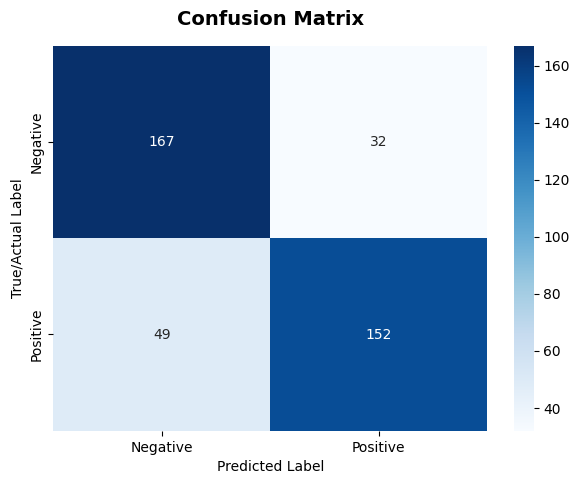

In [7]:
# 1. Menghitung Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy * 100:.2f}%\n")

# 2. Menampilkan Classification Report Detail
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 3. Membuat Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True/Actual Label')
plt.show()

---
## 6. Export Model untuk Website 💾 (SANGAT PENTING)

Model machine learning yang telah kita buat berada dalam memori Jupyter Notebook. Agar website Anda bisa memakainya, kita perlu menyimpan:
1. **Model Klasifikasinya (Classifier)**
2. **TF-IDF Vectorizer-nya**

> **MENGAPA VECTORIZER PERLU DISIMPAN?**
Saat seseorang menginput review baru di website, review teks tersebut harus diconvert menggunakan pembobotan dan kamus kata (*vocabulary*) yang **sama persis** dengan yang dipakai saat model belajar. Jika tidak disimpan, bentuk angkanya akan berbeda dan membuat error/prediksi ngawur.

In [8]:
import os

# Menyimpan file di direktori yang sama dengan notebook ini
output_dir = './'

# Ekspor Model Sentiment (Naive Bayes)
model_filename = os.path.join(output_dir, 'sentiment_model.pkl')
with open(model_filename, 'wb') as file:
    pickle.dump(nb_model, file)
print(f"✅ Berhasil! Model disimpan sebagai: {model_filename}")

# Ekspor TF-IDF Vectorizer
vectorizer_filename = os.path.join(output_dir, 'tfidf_vectorizer.pkl')
with open(vectorizer_filename, 'wb') as file:
    pickle.dump(tfidf, file)
print(f"✅ Berhasil! Vectorizer disimpan sebagai: {vectorizer_filename}")

✅ Berhasil! Model disimpan sebagai: ./sentiment_model.pkl
✅ Berhasil! Vectorizer disimpan sebagai: ./tfidf_vectorizer.pkl


---
## 🎯 Bonus Simulasi: Bagaimana Backend Website Memproses Prediksi?

Cell di bawah ini menggambarkan alur kerja *Backend Server* (misal: Flask, FastAPI, Laravel, atau Django). Skrip di bawah membaca model dari file `.pkl`, membersihkan data inputan user baru, mengubah ke bentuk vektor angka, dan memberikan kesimpulan Positif/Negatif.

In [9]:
# SIMULASI BACKEND WEBSITE

# 1. Memuat (Load) Model dan Vectorizer dari file .pkl yang baru saja diekspor
with open('sentiment_model.pkl', 'rb') as f:
    deployed_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    deployed_vectorizer = pickle.load(f)

def predict_new_review(review_text):
    """
    Fungsi utama yang menerima teks mentah dan mengembalikan label Prediksi Sentimen
    """
    # A. Preprocessing input teks
    cleaned_text = preprocess_text(review_text)
    
    # B. Ekstrak fitur (Ubah ke angka via tfidf)
    # Input ke transform harus berupa Array/List
    text_vector = deployed_vectorizer.transform([cleaned_text])
    
    # C. Prediksi
    prediction = deployed_model.predict(text_vector)
    
    # D. Return hasil
    if prediction[0] == 1:
        return "Positif 🟢"
    else:
        return "Negatif 🔴"

# --- PENGUJIAN --- 
review_user_1 = "This movie is absolutely wonderful! The acting was great and the plot was so engaging."
review_user_2 = "Terrible waste of time. The script is boring and the actors were completely bad."

print(f"Review 1: '{review_user_1}'")
print(f"=> Hasil Prediksi Website: {predict_new_review(review_user_1)}\n")

print(f"Review 2: '{review_user_2}'")
print(f"=> Hasil Prediksi Website: {predict_new_review(review_user_2)}")

Review 1: 'This movie is absolutely wonderful! The acting was great and the plot was so engaging.'
=> Hasil Prediksi Website: Positif 🟢

Review 2: 'Terrible waste of time. The script is boring and the actors were completely bad.'
=> Hasil Prediksi Website: Negatif 🔴
